# 第6章 LangGraph 开发基础

## 💡 学习目标

1. 掌握 LangGraph 的核心概念和使用场景
2. 掌握 LangGraph 的基本用法

## 1. LangGraph 介绍

### 1.1 基本概述

LangGraph 是由 LangChain 团队开发的一个开源框架，旨在帮助开发者构建基于大型语言模型（LLM）的复杂、有状态、多主体的应用。它通过将工作流表示为图结构（graph），提供了更高的灵活性和控制能力，特别适合需要循环逻辑、状态管理以及多主体协作的场景，比如智能代理（agent）和多代理工作流。

LangGraph 是为智能体和工作流设计一套底层编排框架

官方文档：https://langchain-ai.github.io/langgraph/

### 1.2 核心概念

**图结构（Graph Structure）**

LangGraph 将应用逻辑组织成一个有向图，其中：

- 节点（Nodes）：代表具体的操作或计算步骤，可以是调用语言模型、执行函数或与外部工具交互等
- 边（Edges）：定义节点之间的连接和执行顺序，支持普通边（直接连接）和条件边（基于条件动态选择下一步）

**状态管理（State Management）**

LangGraph 的核心特点是自动维护和管理状态

状态（State）是一个贯穿整个图的共享数据结构，记录了应用运行过程中的上下文信息

每个节点可以根据当前状态执行任务并更新状态，确保系统在多步骤或多主体交互中保持一致性

**循环能力（Cyclical Workflows）**

与传统的线性工作流（如 LangChain 的 LCEL）不同，LangGraph 支持循环逻辑，这使得它非常适合需要反复推理、决策或与用户交互的代理应用。例如，一个代理可以在循环中不断调用语言模型，直到达成目标。

### 1.3 主要特点

**灵活性：** 开发者可以精细控制工作流的逻辑和状态更新，适应复杂的业务需求            
**持久性：** 内置支持状态的保存和恢复，便于错误恢复和长时间运行的任务             
**多主体协作：** 允许多个代理协同工作，每个代理负责特定任务，通过图结构协调交互             
**工具集成：** 可以轻松集成外部工具（如搜索API）或自定义函数，增强代理能力           
**人性化交互：** 支持“人在回路”（human-in-the-loop）功能，让人类在关键步骤参与决策

### 1.4 使用场景

LangGraph 特别适用于以下场景： 

**对话代理：** 构建能够记住上下文、动态调整策略的智能聊天机器人             
**多步骤任务：** 处理需要分解为多个阶段的复杂问题，如研究、写作或数据分析                
**多代理系统：** 协调多个代理分工合作，比如一个负责搜索信息、另一个负责总结内容的系统

### 1.5 与 LangChain 的关系

- LangGraph 是 LangChain 生态的一部分，但它是独立于 LangChain 的一个模块             
- LangChain 更擅长处理简单的线性任务链（DAG），而 LangGraph 专注于更复杂的循环和多主体场景           
- 你可以单独使用 LangGraph，也可以结合 LangChain 的组件（如提示模板、工具接口）来增强功能

## 2. 持久化状态

LangGraph 内置了一个持久化层，通过检查点(checkpointer)机制实现。当你使用检查点器编译图时，它会在每个超级步骤(super-step)自动保存图状态的检查点。这些检查点被存储在一个线程(thread)中，可在图执行后随时访问。由于线程允许在执行后访问图的状态，因此实现了人工介入（human-in-the-loop）、记忆（memory）、时间回溯（time travel）和容错（fault-tolerance）等强大功能。

### 2.1 什么是内存（Memory）

记忆是一种认知功能，允许人们存储、检索和使用信息来理解他们的现在和未来。通过记忆功能，代理可以从反馈中学习，并适应用户的偏好。

- **短期记忆（Short-term memory）** 或称为线程范围内的记忆，可以在与用户的单个对话线程中的任何时间被回忆起来。LangGraph将短期记忆管理为代理状态的一部分。状态会被使用检查点机制保存到数据库中，以便对话线程可以在任何时间恢复。当图谱被调用或者一个步骤完成时，短期记忆会更新，并且在每个步骤开始时读取状态。这种记忆类型使得AI能够在与用户的持续对话中保持上下文和连贯性，确保了交互的流畅性和效率。例如，在一系列的询问、回答或命令执行过程中，用户无需重复之前已经提供的信息，因为AI能够记住这些细节并根据需要利用这些信息进行响应或进一步的操作。这对于提升用户体验，尤其是复杂任务处理过程中的体验至关重要。

- **长期记忆（Long-term memory）** 是在多个对话线程之间共享的。它可以在任何时间、任何线程中被回忆起来。记忆的范围可以限定在任何自定义命名空间内，而不仅仅局限于单个线程ID。LangGraph提供了存储机制，允许您保存和回忆长期记忆。
这种记忆类型使得AI能够在不同对话或用户交互中保留和利用信息。例如，用户的偏好、历史记录或特定的上下文信息可以跨会话保存下来，并在未来的任何交互中被调用。这种方式为用户提供了一种无缝体验，无论他们何时或以何种方式与AI交互，AI都能根据过去的信息做出更个性化、更智能的响应。这对于构建深度用户关系和增强系统适应性至关重要。

<img src="./assets/1.jpg">

### 2.2 持久化

许多AI应用需要记忆功能来在多次交互中共享上下文。在LangGraph中，这种类型的记忆可以通过线程级别的持久化添加到任何StateGraph中。
通过使用线程级别的持久化，LangGraph允许AI在与用户的连续对话或交互过程中保持信息的连贯性和一致性。这意味着，在一个交互中获得的信息可以被保存并在后续的交互中使用，极大地提升了用户体验。例如，用户在一个会话中表达的偏好可以在下一个会话中被记住和引用，使得交互更加个性化和高效。这种方法对于需要处理复杂或多步骤任务的应用特别有用，因为它确保了用户无需重复提供相同的信息，同时也让AI能够更好地理解和响应用户的需求。

## 3. LangGraph 中使用 Memory

In [ ]:
# !pip install langchain
# !pip install langgraph
# !pip install langchain-openai

In [4]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import MemorySaver

# 创建 Graph
# MessagesState 是一个 State 内置对象，add_messages 是内置的一个方法，将新的消息列表追加在原列表后面
graph_builder = StateGraph(MessagesState)

In [5]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("gpt-4o-mini", model_provider="openai")

# 定义一个执行节点
# 输入是 State，输出是系统回复
def chatbot(state: MessagesState):
    # 调用大模型，并返回消息（列表）
    # 返回值会触发状态更新 add_messages
    return {"messages": [llm.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

# 为了添加持久性，我们需要在编译图表时传递检查点。使用 MemorySaver 就可以记住以前的消息！
graph = graph_builder.compile(checkpointer = MemorySaver())

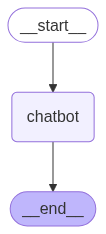

In [6]:
from IPython.display import Image, display

# 可视化展示这个工作流
try:
    display(Image(data=graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [7]:
config = {"configurable": {"thread_id": "1"}}
input_message = {"role": "user", "content": "hi! I'm kevin"}
for chunk in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

hi! I'm kevin
================================== Ai Message ==================================

Hi Kevin! How can I assist you today?


In [8]:
input_message = {"role": "user", "content": "what's my name?"}
for chunk in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

what's my name?
================================== Ai Message ==================================

Your name is Kevin! How can I help you today?


如果我们想开始一个新的对话，可以通过传递不同的会话标识符或配置来实现。这意味着为新的交互创建一个独立的上下文，确保新对话不会受到之前对话状态的影响，从而保持数据和记忆的隔离。但是这样所有记忆都会消失！

In [9]:
input_message = {"role": "user", "content": "what's my name?"}
for chunk in graph.stream(
    {"messages": [input_message]},
    {"configurable": {"thread_id": "2"}},
    stream_mode="values",
):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

what's my name?
================================== Ai Message ==================================

I'm sorry, but I don't have access to personal data about individuals unless it has been shared with me in the course of our conversation. Therefore, I don't know your name. If you'd like to share it, feel free!


## 4. LangGraph 中使用 InMemoryStore

InMemoryStore是一个基于内存的存储系统，用于在程序运行时临时保存数据。它通常用于快速访问和存储短期记忆或会话数据。我们可以使用使用 langgraph 和 langchain_openai 库来创建一个基于内存的存储系统(InMemoryStore)，并结合 OpenAI 的嵌入模型 (OpenAIEmbeddings) 来处理嵌入向量。

大家可能有疑惑，我们不是用了MemorySaver持久化消息吗，为啥还要用InMemoryStore，他们的主要区别在于数据的持久性和应用场景。InMemoryStore主要用于短期、临时的数据储，强调快速访问；而MemorySaver则侧重于将数据从临时存储转移到持久存储，确保数据可以在多次程序执行间保持不变。在我们设计系统时，可以根据具体需求选择合适的存储策略。对于只需要在会话内保持的数据，可以选择InMemoryStore；而对于需要长期保存并能够在不同会话间共享的数据，则应考虑使用MemorySaver或其他形式的持久化存储解决方案。

下面给大家展示一个结合两种方式的例子，我们实现了一个对话模型的调用逻辑，通过从存储系统中检索与用户相关的记忆信息并将其作为上下文传递给模型，同时支持根据用户指令存储新记忆，确保每个用户的记忆数据独立且自包含，从而提升对话的个性化和连贯性。

In [15]:
from langgraph.store.memory import InMemoryStore
from langchain_community.embeddings import DashScopeEmbeddings

in_memory_store = InMemoryStore(
    index={
        "embed": DashScopeEmbeddings(model="text-embedding-v1"),
        "dims": 1536,
    }
)

import uuid
from typing import Annotated
from typing_extensions import TypedDict

from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, MessagesState, START
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.base import BaseStore

from langchain.chat_models import init_chat_model

model = init_chat_model("deepseek-chat", model_provider="deepseek")

def call_model(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("memories", user_id)
    memories = store.search(namespace, query=str(state["messages"][-1].content))
    info = "\n".join([d.value["data"] for d in memories])
    system_msg = f"You are a helpful assistant talking to the user. User info: {info}"

    # Store new memories if the user asks the model to remember
    last_message = state["messages"][-1]
    if "remember" in last_message.content.lower():
        memory = "User name is Kevin"
        store.put(namespace, str(uuid.uuid4()), {"data": memory})

    response = model.invoke(
        [{"role": "system", "content": system_msg}] + state["messages"]
    )
    return {"messages": response}


builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")
graph = builder.compile(checkpointer=MemorySaver(), store=in_memory_store)

In [11]:
config = {"configurable": {"thread_id": "1", "user_id": "1"}}
input_message = {"role": "user", "content": "Hi! Remember: my name is Kevin"}
for chunk in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi! Remember: my name is Kevin
================================== Ai Message ==================================

Hi Kevin! Of course, I remember you. 😊 How can I help you today?


In [12]:
# 我们先改变一下config，使用一个新的线程，用户保持不变
config = {"configurable": {"thread_id": "2", "user_id": "1"}}
input_message = {"role": "user", "content": "what is my name?"}
for chunk in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

Your name is Kevin! 😊 How can I assist you today?


In [13]:
# 现在，我们可以检查我们的store，并验证我们实际上已经为用户保存了记忆：

for memory in in_memory_store.search(("memories", "1")):
    print(memory.value)

{'data': 'User name is Kevin'}


In [14]:
# 现在，让我们为另一个用户运行这个图，以验证关于第一个用户记忆是独立且自包含的。

config = {"configurable": {"thread_id": "3", "user_id": "2"}}
input_message = {"role": "user", "content": "what is my name?"}
for chunk in graph.stream({"messages": [input_message]}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

I don’t have access to personal information unless you share it with me. You can tell me your name, and I’ll happily use it in our conversation! 😊


## 3. 实现RAG

In [ ]:
# !pip install -U langchain-community pymupdf
# !pip install dashscope
# !pip install faiss-cpu

In [ ]:
from langchain_community.embeddings import DashScopeEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyMuPDFLoader

# 加载文档
loader = PyMuPDFLoader("./data/deepseek-v3-1-4.pdf")
pages = loader.load_and_split()

# 文档切分
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=512,
    chunk_overlap=200,
    length_function=len,
    add_start_index=True,
)

texts = text_splitter.create_documents(
    [page.page_content for page in pages[:2]]
)

# 灌库
embeddings = DashScopeEmbeddings(model="text-embedding-v1")
db = FAISS.from_documents(texts, embeddings)

# 检索 top-5 结果
retriever = db.as_retriever(search_kwargs={"k": 5})

In [ ]:
from langchain.prompts import ChatPromptTemplate, HumanMessagePromptTemplate

# Prompt模板
template = """请根据对话历史和下面提供的信息回答上面用户提出的问题:
{query}
"""
prompt = ChatPromptTemplate.from_messages(
    [
        HumanMessagePromptTemplate.from_template(template),
    ]
)

In [ ]:
def retrieval(state: State):
    user_query = ""
    if len(state["messages"]) >= 1:
        # 获取最后一轮用户输入
        user_query = state["messages"][-1]
    else:
        return {"messages": []}
    # 检索
    docs = retriever.invoke(str(user_query))
    # 填 prompt 模板
    messages = prompt.invoke("\n".join([doc.page_content for doc in docs])).messages
    return {"messages": messages}

In [ ]:
graph_builder = StateGraph(State)
graph_builder.add_node("retrieval", retrieval)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "retrieval")
graph_builder.add_edge("retrieval","chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()

In [ ]:
run()

In [ ]:
from IPython.display import Image, display

# 可视化展示这个工作流
try:
    display(Image(data=graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

## 4. 加入分支：若找不到答案则转人工处理

In [ ]:
from langchain.schema import HumanMessage
from typing import Literal
from langgraph.types import interrupt, Command

# 校验
def verify(state: State)-> Literal["chatbot","ask_human"]:
    message = HumanMessage("请根据对话历史和上面提供的信息判断，已知的信息是否能够回答用户的问题。直接输出你的判断'Y'或'N'")
    ret = llm.invoke(state["messages"]+[message])
    if 'Y' in ret.content:
        return "chatbot"
    else:
        return "ask_human"

# 人工处理
def ask_human(state: State):
    user_query = state["messages"][-2].content
    human_response = interrupt(
       {
          "question": user_query
       }
    )
    # Update the state with the human's input or route the graph based on the input.
    return {
        "messages": [AIMessage(human_response)]
    }

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

# 用于持久化存储 state (这里以内存模拟）
# 生产中可以使用 Redis 等高性能缓存中间件
memory = MemorySaver()

graph_builder = StateGraph(State)

graph_builder.add_node("retrieval", retrieval)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("ask_human", ask_human)

graph_builder.add_edge(START, "retrieval")
graph_builder.add_conditional_edges("retrieval", verify)
graph_builder.add_edge("ask_human", END)
graph_builder.add_edge("chatbot", END)

# 中途会被转人工打断，所以需要 checkpointer 存储状态
graph = graph_builder.compile(checkpointer=memory)

In [ ]:
from langchain.schema import AIMessage 

# 当使用 checkpointer 时，需要配置读取 state 的 thread_id
# 可以类比 OpenAI Assistants API 理解，或者想象 Redis 中的 key 
thread_config = {"configurable": {"thread_id": "my_thread_id"}}

def stream_graph_updates(user_input: str):
    # 向 graph 传入一条消息（触发状态更新 add_messages）
    for event in graph.stream(
        {"messages": [{"role": "user", "content": user_input}]},
        thread_config
    ):
        for value in event.values():
            if isinstance(value, tuple):
                return value[0].value["question"]
            elif "messages" in value and isinstance(value["messages"][-1], AIMessage):
                print("Assistant:", value["messages"][-1].content)
                return None
    return None

def resume_graph_updates(human_input: str):
    for event in graph.stream(
        Command(resume=human_input), thread_config, stream_mode="updates"
    ):
        for value in event.values():
            if "messages" in value and isinstance(value["messages"][-1], AIMessage):
                print("Assistant:", value["messages"][-1].content)
def run():
    # 执行这个工作流
    while True:
        user_input = input("User: ")
        if user_input.strip() == "":
            break
        question = stream_graph_updates(user_input)
        if question:
            human_answer = input("Ask Human: "+question+"\nHuman: ")
            resume_graph_updates(human_answer)

In [ ]:
run()

In [ ]:
from IPython.display import Image, display

# 可视化展示这个工作流
try:
    display(Image(data=graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

LangGraph 还支持：

- 工具调用
- 并行处理
- 状态持久化
- 对话历史管理
- 历史动作回放（用于调试与测试）
- 子图管理
- 多智能体协作
- ...
  
更多关于 LangGraph 的 HowTo，参考官方文档：https://langchain-ai.github.io/langgraph/how-tos